NOTE: Code end at cell 20 from EDA...Using "cleaned_sp500.csv" for continued analysis

# Setup

## Loading Libraries

In [1]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss, brier_score_loss, precision_score, recall_score, f1_score,
    roc_curve, auc
)
import pandas_ta as ta
import xgboost as xgb
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Set plotting style for EDA
sns.set_theme(style="whitegrid")

In [2]:
import time
import platform
import psutil
import torch

# Hardware Info
system_info = {}
system_info['python_version'] = platform.python_version()
system_info['system'] = platform.system()
system_info['release'] = platform.release()

# CPU Info
system_info['cpu_name'] = platform.processor()
system_info['cpu_physical_cores'] = psutil.cpu_count(logical=False)
system_info['cpu_logical_cores'] = psutil.cpu_count(logical=True)

# RAM Info
ram_gb = psutil.virtual_memory().total / (1024**3)
system_info['ram_gb'] = f"{ram_gb:.2f} GB"

# GPU Info (checks if PyTorch sees a CUDA-enabled GPU)
try:
    if torch.cuda.is_available():
        system_info['gpu_name'] = torch.cuda.get_device_name(0)
        system_info['gpus_available'] = torch.cuda.device_count()
    else:
        system_info['gpu_name'] = "Not Available / Not Used"
except Exception:
    system_info['gpu_name'] = "Could not check for GPU"

print("\n" + "="*40)
print("           HARDWARE REPORT")
print("="*40)
print(f"System: {system_info['system']} {system_info['release']}")
print(f"CPU: {system_info['cpu_name']}")
print(f"Logical CPUs: {system_info['cpu_logical_cores']}")
print(f"RAM: {system_info['ram_gb']}")
print(f"GPU: {system_info['gpu_name']}")
print("="*40)


           HARDWARE REPORT
System: Windows 10
CPU: Intel64 Family 6 Model 189 Stepping 1, GenuineIntel
Logical CPUs: 8
RAM: 15.66 GB
GPU: Not Available / Not Used


In [3]:
# Notebook runtime tracker (start)
notebook_start_time = time.time()
print("Notebook timer started.")

Notebook timer started.


## Helper functions

In [4]:
# FUNCTION: Displaying columns of missing values and number of missing values
def na_check(df):

    missing = df.isnull().sum()
    
    if missing.sum() == 0:
        print("\nNo missing values found in the DataFrame.")
    else:
        print("\nThere are missing values that need to be handled...\n")
        print("Missing Values per column:")
        print(missing[missing > 0])


In [5]:
# FUNCTION: Getting info on dataset and columns
def unique_table(df):

    # Dataset Info
    unique_tickers = df["Ticker"].unique()
    print("Total Tickers (Companies): ", len(unique_tickers))
    print("Dataset Shape:", df.shape[0], "x", df.shape[1]) 

    # Getting Column Info
    unique_counts = pd.DataFrame({
        'Column': df.columns,
        'Unique': df.nunique().values,
        'Data_Type': df.dtypes.values,
        'Sample_Values': [df[col].unique().tolist() for col in df.columns]
    })

    return unique_counts

## Loading Dataset

In [6]:
# Creating dataframe from .csv
sp500_original = pd.read_csv('final_sp500_data.csv')
# sp500_original = pd.read_csv("cleaned_sp500.csv", parse_dates=["Date"]).set_index(["Ticker", "Ticker"]).sort_index()

# Converting data types
sp500_original['Date'] = pd.to_datetime(sp500_original['Date'])
sp500_original['Sector'] = sp500_original['Sector'].astype('category')
sp500_original['Industry'] = sp500_original['Industry'].astype('category')

# Sort by Ticker, then Date
sp500_original = sp500_original.sort_values(by=['Ticker', 'Date'])

# Confirming dataset
print(sp500_original.shape)

(1883792, 12)


# EDA

### Unique Values

In [7]:
unique = unique_table(sp500_original)
unique

Total Tickers (Companies):  503
Dataset Shape: 1883792 x 12


,Column,Unique,Data_Type,Sample_Values
0,Date,3989,datetime64[ns],"[2010-01-04 00:00:00, 2010-01-05 00:00:00, 201..."
1,Ticker,503,object,"[A, AAPL, ABBV, ABNB, ABT, ACGL, ACN, ADBE, AD..."
2,Company,503,object,"[Agilent Technologies Inc, Apple Inc, AbbVie I..."
3,Sector,11,category,"[Health Care, Information Technology, Consumer..."
4,Industry,129,category,"[Life Sciences Tools & Services, Technology Ha..."
5,Open,1655353,float64,"[19.94887170398882, 19.83448151446589, 19.6056..."
6,High,1658302,float64,"[20.101396541348887, 19.840836222190536, 19.70..."
7,Low,1657181,float64,"[19.78363745202544, 19.54849763720313, 19.5485..."
8,Close,1539422,float64,"[19.89167594909668, 19.67560195922852, 19.6056..."
9,Volume,382897,int64,"[3815561, 4186031, 3243779, 3095172, 3733918, ..."


### Missing Values (Initial) and Heatmap of Missing Values


No missing values found in the DataFrame.


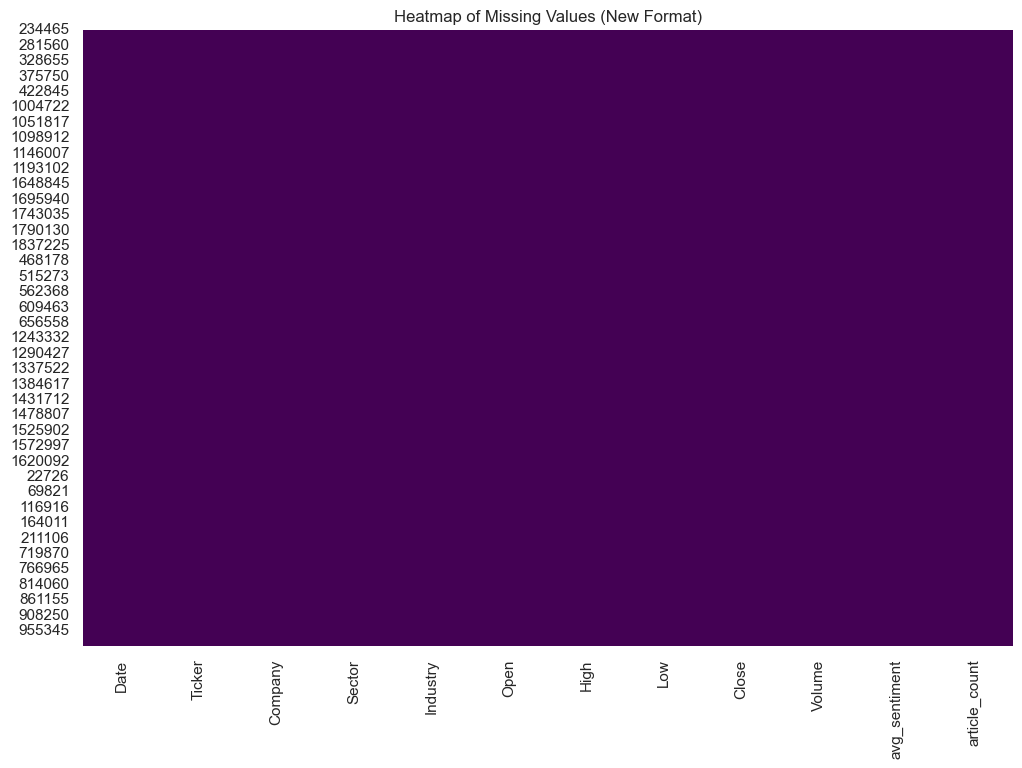

In [8]:
na_check(sp500_original)

# Create a heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(sp500_original.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values (New Format)')
plt.show()


## Feature Engineering

Additional columns are added prior to cutoff date.

In [9]:
# Creating seperate dataframe for analysis
df = sp500_original.copy()
df.columns


Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count'],
      dtype='object')

#### Price and Volume Momentum Features

In [10]:
# FUNCTION: Adding Feature Engineering
def build_model_table(df):
    print("Calculating momentum features...")

    # Creating Multi-day percentage changes
    periods = {'daily':1, 'weekly': 5, 'monthly': 21}
    for name, period in periods.items():
        df[f'{name}_return'] = df.groupby('Ticker')['Close'].pct_change(periods=period)
        df[f'{name}_vol'] = df.groupby('Ticker')['Volume'].pct_change(periods=period)

    # Creating lagging daily returns (up to 5 days)
    for lag in range(1, 6):
        df[f'returns(-{lag}D)'] = df.groupby('Ticker')['daily_return'].shift(lag)

    # Creating additional columns
    df["price_mean_5d"] = df.groupby('Ticker')["Close"].transform(lambda s: s.rolling(5, min_periods=5).mean())
    df["price_mean_10d"] = df.groupby('Ticker')["Close"].transform(lambda s: s.rolling(10, min_periods=10).mean())

    df["return_1d_minus_date_mean"] = df["daily_return"] - df.groupby("Date")["daily_return"].transform("mean")
    df["return_5d_minus_date_mean"] = df["weekly_return"] - df.groupby("Date")["weekly_return"].transform("mean")
    # df["sentiment_score_minus_date_mean"] = df["sentiment_score"] - df.groupby("Date")["sentiment_score"].transform("mean")

    df["log_article_count"] = np.log1p(df["article_count"])
    df["article_count_rank_date"] = df.groupby("Date")["article_count"].rank(pct=True)
    df["article_count_minus_date_mean"] = df["article_count"] - df.groupby("Date")["article_count"].transform("mean")
    df["rolling_article_count_5d"] = df.groupby('Ticker')["article_count"].transform(lambda s: s.rolling(5, min_periods=5).mean())
    # df["rolling_has_articles_5d"] = df.groupby('Ticker')["has_articles"].transform(lambda s: s.rolling(5, min_periods=5).mean())

    # Target Feature: 1 if next day's close is strictly greater than today's close, 0 otherwise
    df['target_next_day_direction'] = (df.groupby('Ticker')['Close'].shift(-1) > df['Close']).astype(int)

    # Filtering by GDELT 2.0 cutoff date
    gdelt_cutoff_date = pd.to_datetime('2015-02-19')
    df = df[df['Date'] >= gdelt_cutoff_date]

    # Droping remaining rows with missing values created by the lagging/rolling functions
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    print("Completed...")
    na_check(df)

    return(df)


#### Dataset after Feature Engineering

In [11]:
# Feature Engineering
df = build_model_table(df)

# Displaying final dataset after feature engineering
print("Feature engineering complete!")
print(f"Final shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(df.columns)
df.head()

Calculating momentum features...
Completed...

No missing values found in the DataFrame.
Feature engineering complete!
Final shape: 1309511 rows x 32 columns
Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count',
       'daily_return', 'daily_vol', 'weekly_return', 'weekly_vol',
       'monthly_return', 'monthly_vol', 'returns(-1D)', 'returns(-2D)',
       'returns(-3D)', 'returns(-4D)', 'returns(-5D)', 'price_mean_5d',
       'price_mean_10d', 'return_1d_minus_date_mean',
       'return_5d_minus_date_mean', 'log_article_count',
       'article_count_rank_date', 'article_count_minus_date_mean',
       'rolling_article_count_5d', 'target_next_day_direction'],
      dtype='object')


C:\Users\crist\AppData\Local\Temp\ipykernel_16872\998668976.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,...,returns(-5D),price_mean_5d,price_mean_10d,return_1d_minus_date_mean,return_5d_minus_date_mean,log_article_count,article_count_rank_date,article_count_minus_date_mean,rolling_article_count_5d,target_next_day_direction
0,2015-02-19,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.889730,38.045314,37.560253,37.660927,3737300,...,-0.008571,37.227121,36.634975,-0.009706,0.027646,1.386294,0.847403,-1.138528,0.6,1
1,2015-02-20,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.606019,38.539534,37.413825,38.393101,2971900,...,0.017544,37.580393,36.856457,0.012499,0.034032,1.098612,0.822126,-1.609544,1.0,0
2,2015-02-23,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.338183,38.402248,37.972101,38.191750,1967900,...,0.003249,37.869596,37.075194,-0.004531,0.029186,0.693147,0.719089,-3.106291,1.2,1
3,2015-02-24,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.091068,38.539523,38.072763,38.493763,1922100,...,0.009215,38.151479,37.351588,0.005855,0.026862,0.693147,0.764642,-3.355748,1.4,1
4,2015-02-25,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.750024,38.887307,38.521221,38.621895,2343500,...,0.025173,38.272287,37.583136,0.003403,0.007382,1.386294,0.851410,-0.806941,2.0,1


In [12]:
# FUNCTION: Getting class proportions of a column
def class_proportion(df, column_name):

    # Getting Counts and Percentages from column
    counts = df[column_name].value_counts()
    percentages = df[column_name].value_counts(normalize=True) * 100

    # Combining into a DataFrame
    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.map('{:.2f}%'.format)
    })

    # Converting index into a column, then rename the new column
    summary = summary.reset_index().rename(columns={'index': 'Direction'})

    print(f'\n--- Proportion: {column_name} ---')
    print(summary.to_string(index=False))

# Displaying results
class_proportion(df, 'target_next_day_direction')



--- Proportion: target_next_day_direction ---
 target_next_day_direction  Count Percentage
                         1 685259     52.33%
                         0 624252     47.67%


## Time Frame settings

In [13]:
# FUNCTION: Setting Timeframe
def filter_dataframe_by_years(df, years_to_keep):

    # Finding the most recent date in the DataFrame
    last_date = df['Date'].max()

    # Calculating the date 5 years ago from the last date
    five_years_ago = last_date - pd.DateOffset(years=years_to_keep)

    # Creating a new DataFrame containing only the data from the last 5 years
    df_timeframe = df[df['Date'] >= five_years_ago].copy()

    print(f"Original df has data from {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"New df has data from {df_timeframe['Date'].min().date()} to {df_timeframe['Date'].max().date()}\n")
    
    return df_timeframe

# Now, call the function to create your df_timeframe
df_timeframe = filter_dataframe_by_years(df, years_to_keep=5)

Original df has data from 2015-02-19 to 2025-11-10
New df has data from 2020-11-10 to 2025-11-10



In [14]:
df_timeframe.shape

(624199, 32)

## Summary Statistics

In [15]:
# Summary Statistics

# Creating columns to Summarize
columns_to_summarize = ['daily_vol']

# Group by 'Ticker' and calculate descriptive statistics for the selected columns
summary_ticker = df_timeframe.groupby('Ticker')[columns_to_summarize].describe()
summary_sector = df_timeframe.groupby('Sector')[columns_to_summarize].describe()
summary_industry = df_timeframe.groupby('Industry')[columns_to_summarize].describe()


C:\Users\crist\AppData\Local\Temp\ipykernel_16872\4169010552.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sector = df_timeframe.groupby('Sector')[columns_to_summarize].describe()
C:\Users\crist\AppData\Local\Temp\ipykernel_16872\4169010552.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_industry = df_timeframe.groupby('Industry')[columns_to_summarize].describe()


In [16]:
summary_sector

daily_vol                                             \
                           count      mean          std       min       25%   
Sector                                                                        
Communication Services   30144.0  0.093116     0.585307 -0.921695 -0.209351   
Consumer Discretionary   61461.0  0.074841     0.479102 -0.938187 -0.200111   
Consumer Staples         45828.0  0.082924     0.780202 -0.990953 -0.200821   
Energy                   27549.0  0.074387     0.497662 -0.944313 -0.193106   
Financials               93874.0  0.080670     0.604693 -0.990363 -0.202463   
Health Care              73943.0  0.088574     0.857939 -0.993423 -0.211370   
Industrials              97606.0  0.083042     0.511605 -0.958760 -0.210018   
Information Technology   85281.0  0.084742     0.525905 -0.957824 -0.210869   
Materials                30961.0  7.416568  1277.897030 -0.998788 -0.211459   
Real Estate              38936.0  0.084804     0.520936 -0.932682 -0.207269   
Utilities                38616.0  0.080047     0.493330 -0.890548 -0.203709   

                                                           
                             50%       75%            max  
Sector                                                     
Communication Services -0.016454  0.244329      17.974711  
Consumer Discretionary -0.013631  0.234174      17.506200  
Consumer Staples       -0.013377  0.232462     125.014286  
Energy                 -0.011201  0.221277      16.088907  
Financials             -0.011451  0.236032      80.939439  
Health Care            -0.012326  0.248674     184.493827  
Industrials            -0.011739  0.249057      17.035345  
Information Technology -0.013135  0.251048      22.842506  
Materials              -0.012696  0.251467  224854.666667  
Real Estate            -0.008488  0.247684      12.439327  
Utilities              -0.009151  0.245291       9.725439

### PLOT: Daily Sentiment (Sector Comparison)

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\2585475256.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_5_sectors = df_timeframe.groupby('Sector')['article_count'].sum().index.tolist()


Top 5 Sectors by Article Volume: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']


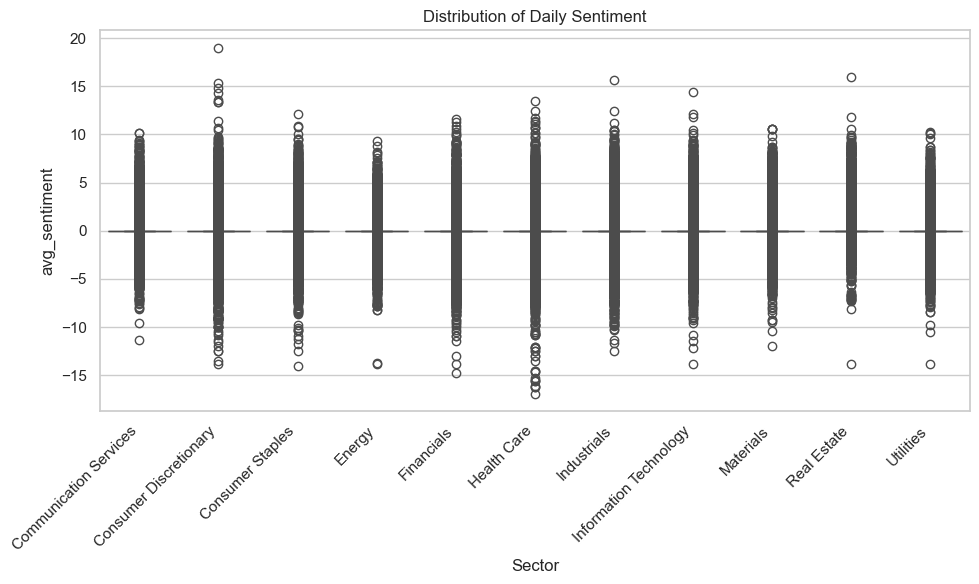

In [17]:
# Identifying Top 5 Sectors by total article volume
top_5_sectors = df_timeframe.groupby('Sector')['article_count'].sum().index.tolist()
print(f"Top 5 Sectors by Article Volume: {top_5_sectors}")

# Filtering the dataset for only these top 5 sectors
df_sector = df_timeframe[df_timeframe['Sector'].isin(top_5_sectors)]

# Comparing Average Sentiment across Top 5 Sectors
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sector', y='avg_sentiment', data=df_sector)
plt.title('Distribution of Daily Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PLOT: Daily Return Volatility (Sector Comparison)

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\2782178695.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_volatility = df_sector.groupby('Sector')['daily_return'].std().reset_index()


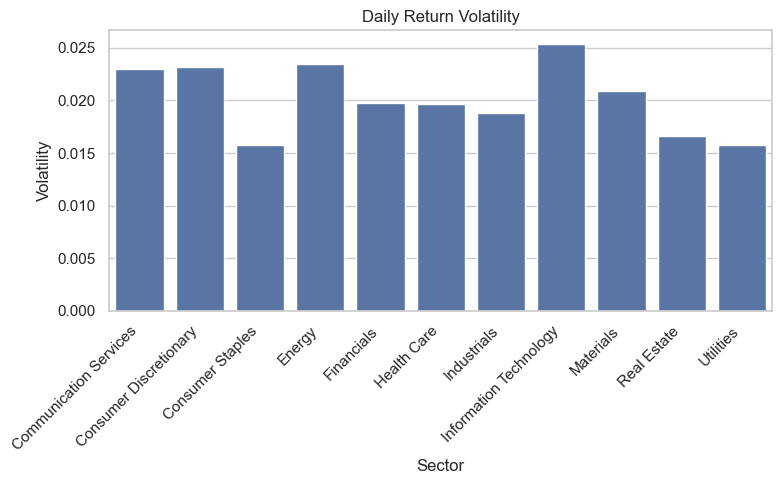

In [18]:
# Comparing Volatility (Risk) across Top 5 Sectors

# Volatility is calculated as the standard deviation of daily returns
sector_volatility = df_sector.groupby('Sector')['daily_return'].std().reset_index()
sector_volatility.rename(columns={'daily_return': 'Volatility'}, inplace=True)

# Plotting daily return volatility
plt.figure(figsize=(8, 5))
sns.barplot(x='Sector', y='Volatility', data=sector_volatility)
plt.title('Daily Return Volatility')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PLOT: Distrubition of Daily Sentiment (Top 10 Most Talked about Industries)

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\3179655261.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_industries = df_timeframe.groupby('Industry')['article_count'].sum().nlargest(10).index.tolist()
C:\Users\crist\AppData\Local\Temp\ipykernel_16872\3179655261.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


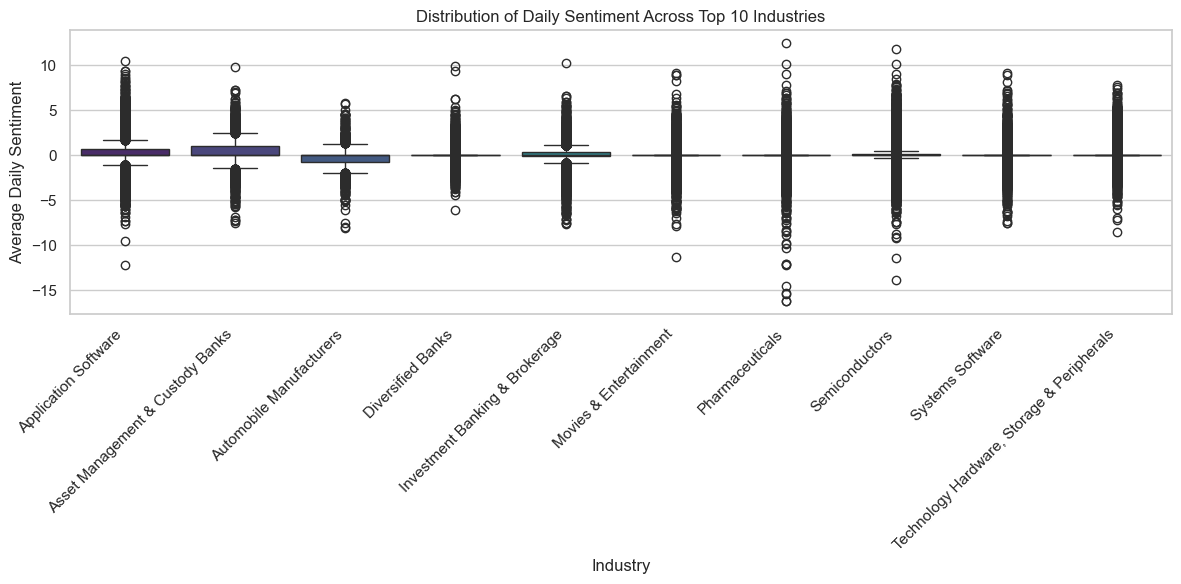

In [19]:
# Identify the Top 10 Industries by total article volume
top_10_industries = df_timeframe.groupby('Industry')['article_count'].sum().nlargest(10).index.tolist()

# Filter the dataset and make a copy to avoid warnings
df_top10_ind = df_timeframe[df_timeframe['Industry'].isin(top_10_industries)].copy()

# Fix the x-axis text overlap by converting to standard strings
df_top10_ind['Industry'] = df_top10_ind['Industry'].astype(str)

# Calculate the median sentiment for these top 10 to sort the plot
industry_order = df_top10_ind.groupby('Industry')['avg_sentiment'].median().sort_values(ascending=False).index

# Create the improved boxplot WITH the outlier dots
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Industry', 
    y='avg_sentiment', 
    data=df_top10_ind, 
    order=industry_order, 
    palette='viridis'
    # showfliers=False has been removed, so the dots will return!
)

plt.title('Distribution of Daily Sentiment Across Top 10 Industries')
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Average Daily Sentiment')
plt.tight_layout()
plt.show()

### Correlation Map

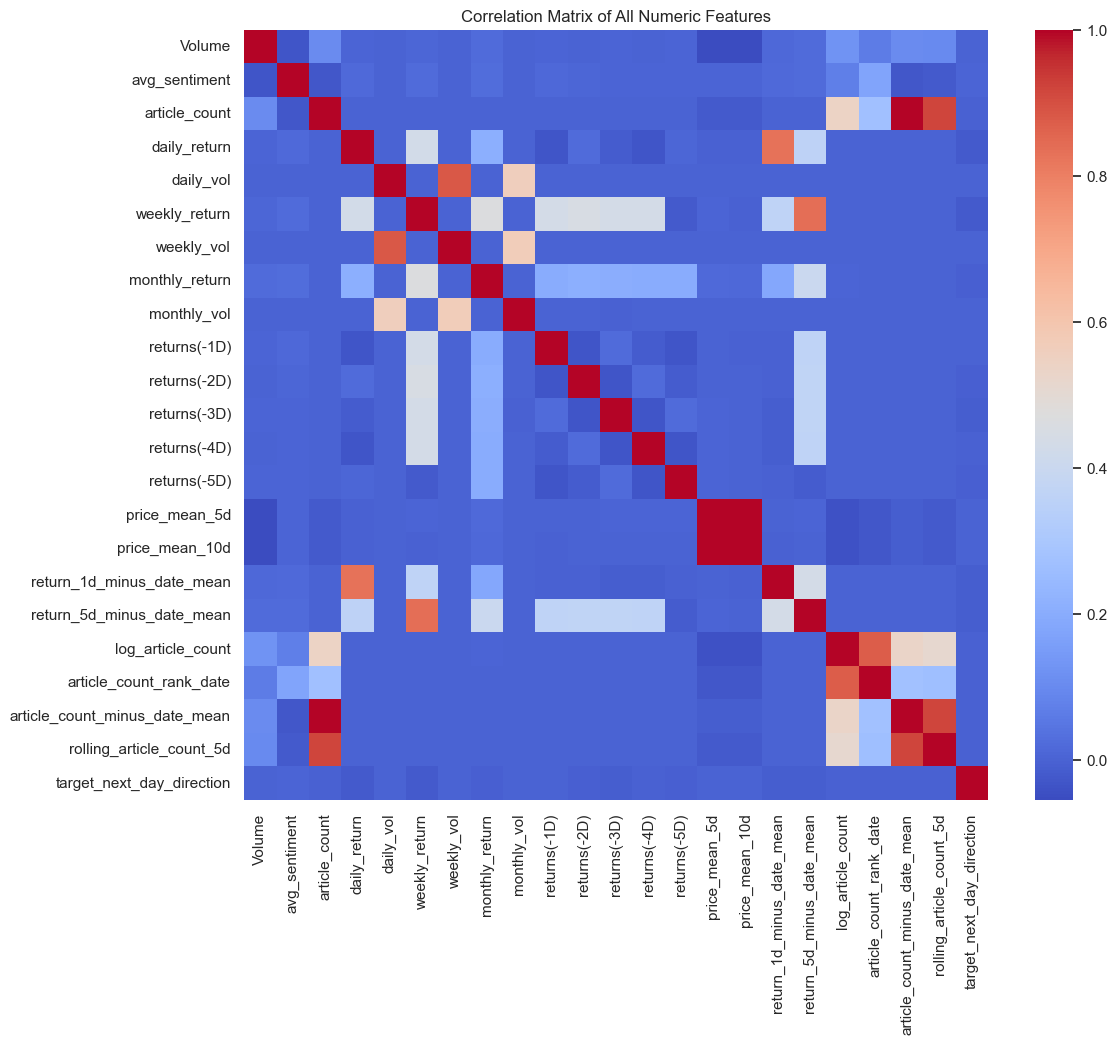

In [20]:
# Select only numeric columns for the correlation matrix
numeric_cols = df.select_dtypes(include=np.number)
raw_prices = ['Open', 'High', 'Low', 'Close']
numeric_cols = numeric_cols.drop(columns = raw_prices)

corr_matrix = numeric_cols.corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of All Numeric Features')
plt.show()

### Moving Average of Articles (Sector)

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\2013395066.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sector_articles = df_timeframe.groupby(['Date', 'Sector'])['article_count'].sum().reset_index()


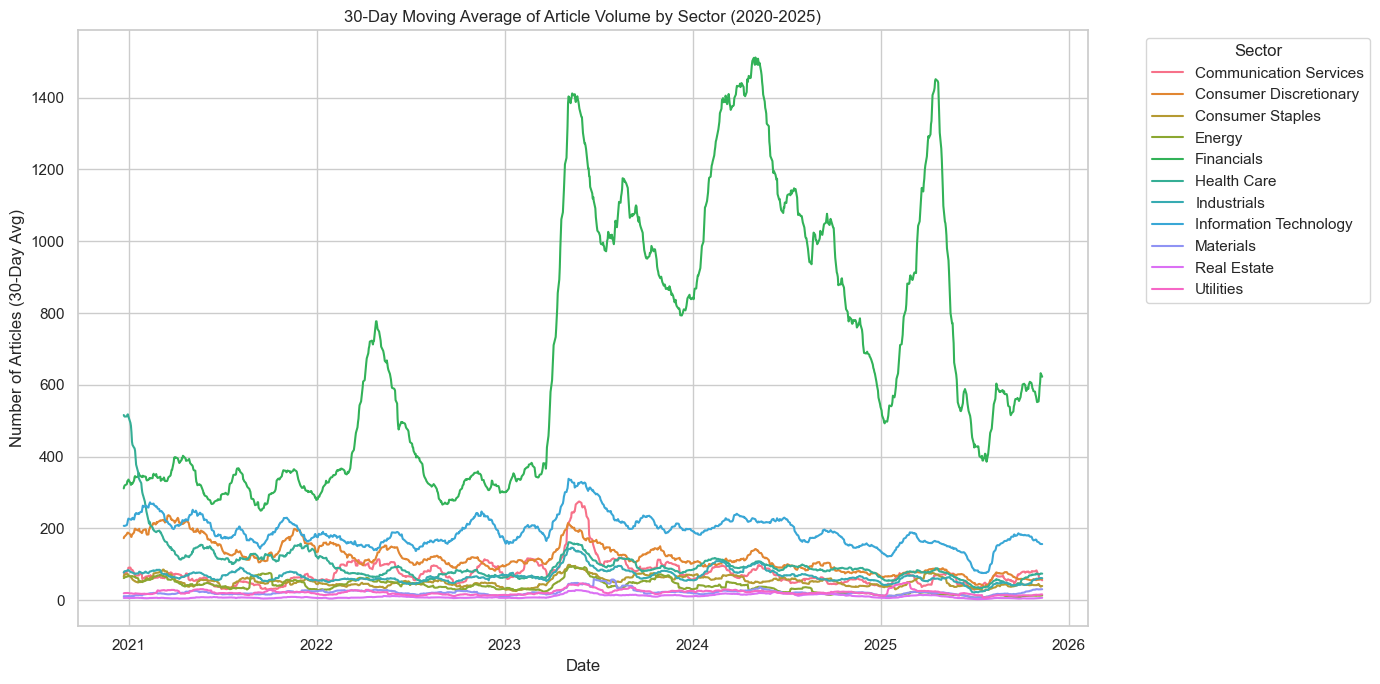

In [21]:
# Grouping by Date and Sector, summing the daily articles to get the total per sector per day
daily_sector_articles = df_timeframe.groupby(['Date', 'Sector'])['article_count'].sum().reset_index()

# Pivoting the dataframe so Dates are the index and Sectors are the columns
pivot_articles = daily_sector_articles.pivot(index='Date', columns='Sector', values='article_count')

# Applying a 30-day rolling average to smooth the data for readability
smoothed_articles = pivot_articles.rolling(window=30).mean()

# Creating the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_articles, dashes=False, linewidth=1.5)

plt.title('30-Day Moving Average of Article Volume by Sector (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Number of Articles (30-Day Avg)')

# Move the legend outside the plot so it doesn't cover the data lines
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Moving average of Daily Returns by sector (2023)

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\3735608676.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sector_returns = df_year.groupby(['Date', 'Sector'])['daily_return'].mean().reset_index()


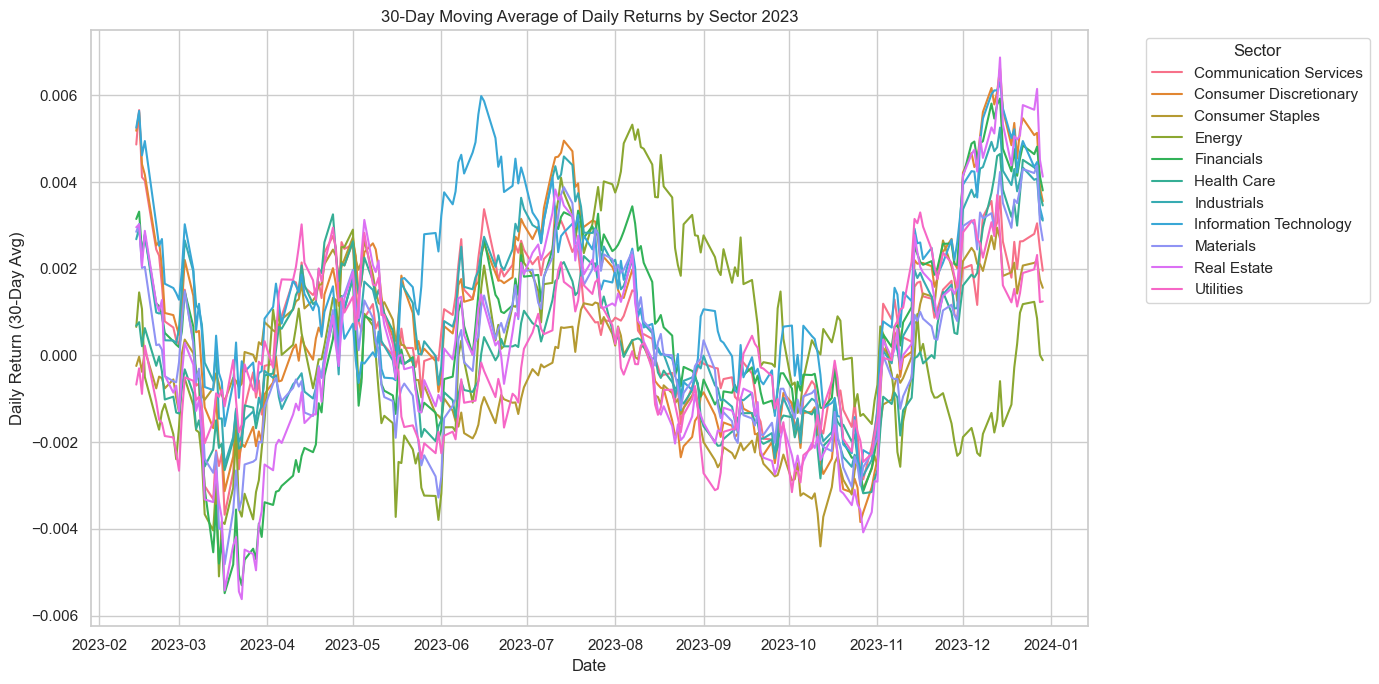

In [22]:
# Creating variables for date filtering and window-period
year = 2023
start_date = pd.to_datetime(f'{year}-01-01')
end_date = pd.to_datetime(f'{year}-12-31')
df_year = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
moving_avg_period = 30

# PLOT 1: 30-Day Moving Average of Daily Returns by Sector

# Calculating the mean daily return for each sector on each day
daily_sector_returns = df_year.groupby(['Date', 'Sector'])['daily_return'].mean().reset_index()

# Pivoting so Date is the index and Sectors are the columns
pivot_sector_returns = daily_sector_returns.pivot(index='Date', columns='Sector', values='daily_return')

# Applying a 30-day rolling average to smooth the volatility
smoothed_sector_returns = pivot_sector_returns.rolling(window=moving_avg_period).mean()

# Creating the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_sector_returns, dashes=False, linewidth=1.5)

plt.title(f'{moving_avg_period}-Day Moving Average of Daily Returns by Sector {year}')
plt.xlabel('Date')
plt.ylabel(f'Daily Return ({moving_avg_period}-Day Avg)')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



### Moving Average of Daily Returns (by period window) by Top Industries

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\3737161233.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_15_industries_20 = df_year.groupby('Industry')['article_count'].sum().nlargest(top_n).index.tolist()


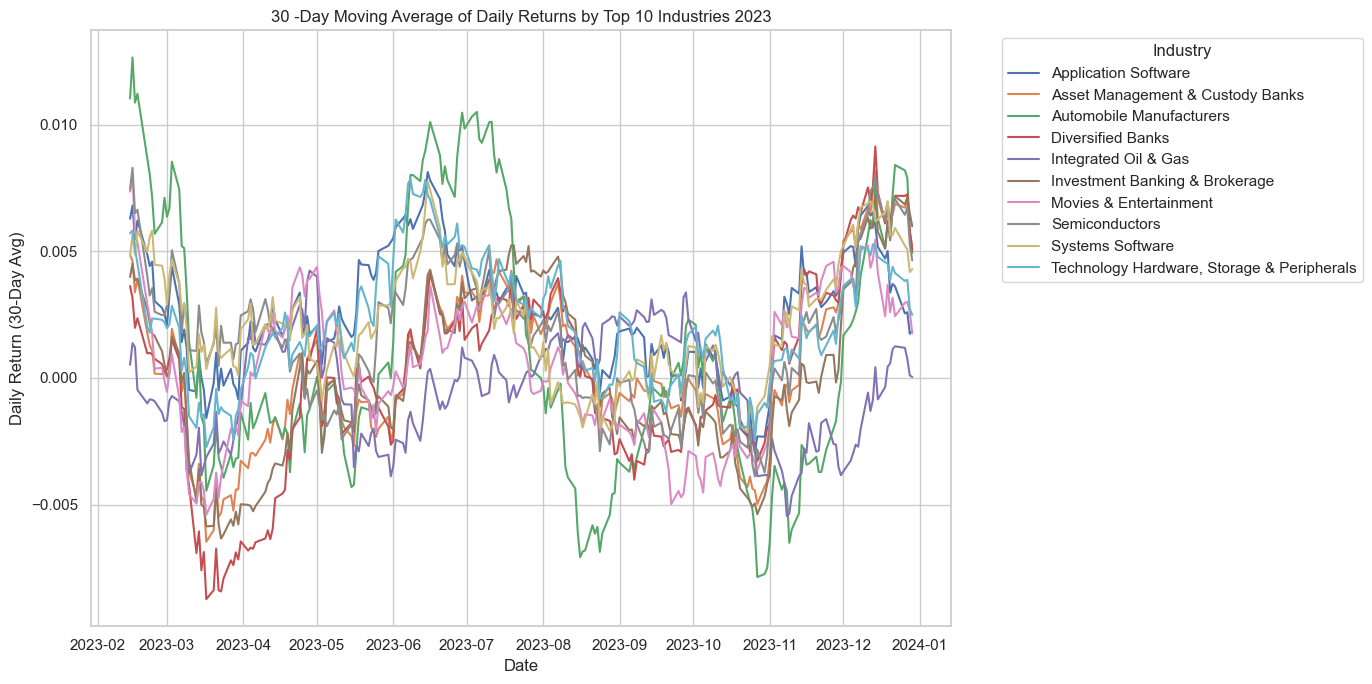

In [23]:
# PLOT 2: Moving Average of Daily Returns (by period window) by Top Industries

top_n = 10

# Identifying Top Industries by total article volume within the 2020-2024 timeframe
top_15_industries_20 = df_year.groupby('Industry')['article_count'].sum().nlargest(top_n).index.tolist()

# Filtering the dataset and make a copy to avoid warnings
df_top15_ind_20 = df_year[df_year['Industry'].isin(top_15_industries_20)].copy()

# Converting 'Industry' to standard strings so pandas forgets the other industries!
df_top15_ind_20['Industry'] = df_top15_ind_20['Industry'].astype(str)

# Calculating mean daily return for each industry on each day
daily_industry_returns_20 = df_top15_ind_20.groupby(['Date', 'Industry'])['daily_return'].mean().reset_index()

# Pivoting so Date is the index and Industries are the columns
pivot_industry_returns_20 = daily_industry_returns_20.pivot(index='Date', columns='Industry', values='daily_return')

# Applying the 15-day rolling average
smoothed_industry_returns_20 = pivot_industry_returns_20.rolling(window=moving_avg_period).mean()

# Creating the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_industry_returns_20, dashes=False, linewidth=1.5)

plt.title(f'{moving_avg_period} -Day Moving Average of Daily Returns by Top {top_n} Industries {year}')
plt.xlabel('Date')
plt.ylabel(f'Daily Return ({moving_avg_period}-Day Avg)')
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
df.head()

,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,...,returns(-5D),price_mean_5d,price_mean_10d,return_1d_minus_date_mean,return_5d_minus_date_mean,log_article_count,article_count_rank_date,article_count_minus_date_mean,rolling_article_count_5d,target_next_day_direction
0,2015-02-19,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.889730,38.045314,37.560253,37.660927,3737300,...,-0.008571,37.227121,36.634975,-0.009706,0.027646,1.386294,0.847403,-1.138528,0.6,1
1,2015-02-20,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.606019,38.539534,37.413825,38.393101,2971900,...,0.017544,37.580393,36.856457,0.012499,0.034032,1.098612,0.822126,-1.609544,1.0,0
2,2015-02-23,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.338183,38.402248,37.972101,38.191750,1967900,...,0.003249,37.869596,37.075194,-0.004531,0.029186,0.693147,0.719089,-3.106291,1.2,1
3,2015-02-24,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.091068,38.539523,38.072763,38.493763,1922100,...,0.009215,38.151479,37.351588,0.005855,0.026862,0.693147,0.764642,-3.355748,1.4,1
4,2015-02-25,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.750024,38.887307,38.521221,38.621895,2343500,...,0.025173,38.272287,37.583136,0.003403,0.007382,1.386294,0.851410,-0.806941,2.0,1


# Models

## Train / Test Split (numerical only)

80/20 split
    - sorted by date not group to avoid leakage for split


### Option 1: 80/20 split

In [25]:
# Sorting by date
df_date_sorted = df.sort_values(by='Date').copy()

# Finding date point that is at 80%
unique_dates = df_date_sorted['Date'].unique()
split_index = int(len(unique_dates)*0.8)
cutoff_date = unique_dates[split_index]

# Gettin start and end dates
start_date = df_date_sorted['Date'].min()
end_date = df_date_sorted['Date'].max()

print(f"Data ranges from: {start_date.date()} to {end_date.date()}")
print(f"Splitting data at cutoff date: {cutoff_date}")

Data ranges from: 2015-02-19 to 2025-11-10
Splitting data at cutoff date: 2023-09-18 00:00:00


In [26]:
# Train / Test Split using filtered cuttoff date
train = df_date_sorted[df_date_sorted['Date'] < cutoff_date]
test = df_date_sorted[df_date_sorted['Date'] >= cutoff_date]

# Creating list of features to exclude
exclude_columns = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    'Sector', 'Industry',               # Categorical
    'Open', 'High', 'Low', 'Close',     # Raw prices (use engineered features instead)
    'Volume',                           # Raw volume
    'target_next_day_direction'         # The target variable
]

# Separating included features (X) and target (y)
X_train = train.drop(columns = exclude_columns)
y_train = train['target_next_day_direction']

X_test = test.drop(columns = exclude_columns)
y_test = test['target_next_day_direction']

# Verify the shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Optional: Print the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train.columns)

X_train shape: (1039415, 21)
y_train shape: (1039415,)
X_test shape: (270096, 21)
y_test shape: (270096,)

Features used for modeling:
Index(['avg_sentiment', 'article_count', 'daily_return', 'daily_vol',
       'weekly_return', 'weekly_vol', 'monthly_return', 'monthly_vol',
       'returns(-1D)', 'returns(-2D)', 'returns(-3D)', 'returns(-4D)',
       'returns(-5D)', 'price_mean_5d', 'price_mean_10d',
       'return_1d_minus_date_mean', 'return_5d_minus_date_mean',
       'log_article_count', 'article_count_rank_date',
       'article_count_minus_date_mean', 'rolling_article_count_5d'],
      dtype='object')


### Model: Majority and Random Baselines

In [27]:
# FUNCTION: Getting Metrics for Evaluation
def metrics(model_name, y_true, y_pred, y_prob):

    # Getting Metrics Values
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)

    # Print Confusion Matrix
    print(f'\n--- Confusion Matrix: {model_name} ---')
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm, 
        index=['Actual 0', 'Actual 1'], 
        columns=['Predicted 0', 'Predicted 1'])
    print(cm_df)

    # Python has diffent matrix setup than R...
    #           Predicted
    #             0   1
    # Actual 0 [[TN, FP],
    #        1  [FN, TP]]
    
    TN, FP, FN, TP = cm.ravel()
    print(f"\nTrue Negatives (TN):  {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")
    print(f"True Positives (TP):  {TP}")

    # Creating dictionary for dataframe return
    metrics_dict = {
        'Model': [model_name],
        'Accuracy': [accuracy],
        'ROC-AUC': [roc_auc],
        'F1 Score': [f1],
        'Precision': [precision],
        'Recall': [recall]
    }

    return pd.DataFrame(metrics_dict)

In [28]:

# MODEL: MAJORITY BASELINE
majority_class = y_train.mode()[0]
y_pred_majority = np.full(len(y_test), majority_class)
y_prob_majority = np.full(len(y_test), majority_class)

majority_metrics = metrics('Majority Baseline', y_test, y_pred_majority, y_prob_majority)


# MODEL: RANDOM BASELINE
p = y_train.mean() # The historical probability of Class 1 ('Up')
y_pred_random = np.random.binomial(1, p, size=len(y_test))
y_prob_random = np.full(len(y_test), p)

random_metrics = metrics('Random Baseline', y_test, y_pred_random, y_prob_random)


--- Confusion Matrix: Majority Baseline ---
          Predicted 0  Predicted 1
Actual 0            0       128771
Actual 1            0       141325

True Negatives (TN):  0
False Positives (FP): 128771
False Negatives (FN): 0
True Positives (TP):  141325

--- Confusion Matrix: Random Baseline ---
          Predicted 0  Predicted 1
Actual 0        61558        67213
Actual 1        67597        73728

True Negatives (TN):  61558
False Positives (FP): 67213
False Negatives (FN): 67597
True Positives (TP):  73728


In [29]:
# Displaying metrics from models
model_results = pd.concat([majority_metrics, random_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
Majority Baseline,0.523240,0.500000,0.687009,0.523240,1.000000
Random Baseline,0.500881,0.500000,0.522401,0.523113,0.521691


### Model: Random Forest (Initial - Numeric Only)

In [30]:
# Preparing parameters for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [200],              # Number of trees
    'max_depth': [10, 20],              # Maximum depth to prevent overfitting
    'min_samples_leaf': [10, 50]        # Minimum samples in a leaf to ensure generalizable rules
}

# Initializing the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Setting up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',  
    verbose=2,          
    n_jobs=-1           
)

# Training the model using Grid Search
print("Starting GridSearchCV... (Grab a coffee, this will take some time!)")
grid_search.fit(X_train, y_train)

# Displaying the Best Parameters and the Best Model
print("\n--- GRID SEARCH COMPLETE ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

# Predicting on the test set
print("\nMaking predictions on the test set...")
y_pred_rf = best_rf_model.predict(X_test)           
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]


Starting GridSearchCV... (Grab a coffee, this will take some time!)


Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- GRID SEARCH COMPLETE ---
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
Best Cross-Validation AUC: 0.5029

Making predictions on the test set...


In [31]:
# Getting metrics of Random Forest (Numeric)
rf_num_metrics = metrics('Random Forest (Numeric)', y_test, y_pred_rf, y_prob_rf)

# Displaying metrics from models
model_results = pd.concat([model_results, rf_num_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Confusion Matrix: Random Forest (Numeric) ---
          Predicted 0  Predicted 1
Actual 0         7734       121037
Actual 1         7640       133685

True Negatives (TN):  7734
False Positives (FP): 121037
False Negatives (FN): 7640
True Positives (TP):  133685


--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
Majority Baseline,0.523240,0.500000,0.687009,0.523240,1.000000
Random Baseline,0.500881,0.500000,0.522401,0.523113,0.521691
Random Forest (Numeric),0.523588,0.511108,0.675097,0.524827,0.945940


--- FEATURE IMPORTANCE SCORES ---
                      Feature  Importance
article_count_minus_date_mean    0.191607
      article_count_rank_date    0.161299
                 daily_return    0.082709
                 returns(-5D)    0.064640
                 returns(-1D)    0.060162
                weekly_return    0.052317
                 returns(-3D)    0.049587
                 returns(-2D)    0.045329
               monthly_return    0.039227
                 returns(-4D)    0.038217
    return_5d_minus_date_mean    0.037673
    return_1d_minus_date_mean    0.037645
                    daily_vol    0.027361
                   weekly_vol    0.024716
                  monthly_vol    0.024686
               price_mean_10d    0.014459
                price_mean_5d    0.014241
                article_count    0.008726
            log_article_count    0.008680
     rolling_article_count_5d    0.008665
                avg_sentiment    0.008054


C:\Users\crist\AppData\Local\Temp\ipykernel_16872\1628468333.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


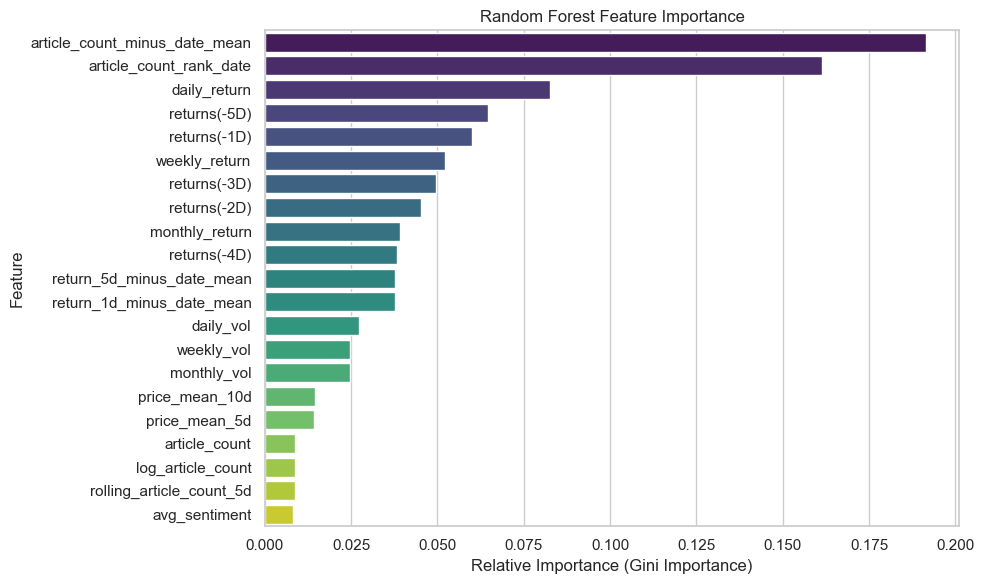

In [32]:
# Extracting the feature names and importances from best tuned model
feature_names = best_rf_model.feature_names_in_
importances = best_rf_model.feature_importances_

# Creating a DataFrame pairing the feature names with their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Displaying the exact numeric values
print("--- FEATURE IMPORTANCE SCORES ---")
print(feature_importance_df.to_string(index=False))

# Creating a horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model: XGBoost Classifier (Initial - Numeric Only)

In [33]:
# Creating list columns to exclude
exclude_columns_xgb = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    'Sector', 'Industry',               # Categorical
    'Open', 'High', 'Low', 'Close',     # Raw prices
    'Volume',                           # Raw Volume
    'target_next_day_direction'         # The target variable
]

# Splitting train/test datasets
X_train_xgb = train.drop(columns = exclude_columns_xgb)
y_train_xgb = train['target_next_day_direction']

X_test_xgb = test.drop(columns = exclude_columns_xgb)
y_test_xgb = test['target_next_day_direction']

# Printing the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train_xgb.columns)


Features used for modeling:
Index(['avg_sentiment', 'article_count', 'daily_return', 'daily_vol',
       'weekly_return', 'weekly_vol', 'monthly_return', 'monthly_vol',
       'returns(-1D)', 'returns(-2D)', 'returns(-3D)', 'returns(-4D)',
       'returns(-5D)', 'price_mean_5d', 'price_mean_10d',
       'return_1d_minus_date_mean', 'return_5d_minus_date_mean',
       'log_article_count', 'article_count_rank_date',
       'article_count_minus_date_mean', 'rolling_article_count_5d'],
      dtype='object')


## Model: XGBoost Classifier (Numerical)

In [34]:
# Defining parameters
tscv_xgb = TimeSeriesSplit(n_splits=5)
param_grid_xgb = {
    'n_estimators': [50, 75, 100, 150],
    'max_depth': [3, 5, 6, 7, 8],
    'learning_rate': [0.05, 0.1]
}

# Initializing the base XGBoost model
xgb_num_model = XGBClassifier(
    # tree_method='hist',           # Use to include categorical
    # enable_categorical=True,      # Use to include categorical
    random_state=42,
    n_jobs=-1
)

# Setting up the Grid Search
grid_search_xgb = GridSearchCV(
    estimator=xgb_num_model,
    param_grid=param_grid_xgb,
    cv=tscv_xgb,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

# Running the search on your training data
print("Searching for the best parameters. This may take a moment...")
grid_search_xgb.fit(X_train_xgb, y_train_xgb)


Searching for the best parameters. This may take a moment...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [50, 75, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [35]:
# Viewing the results of hyperparameters
best_xgb_model = grid_search_xgb.best_estimator_
print("\n--- XGBOOST GRID SEARCH COMPLETE ---")
print(f"Best Hyperparameters: {grid_search_xgb.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search_xgb.best_score_:.4f}")

# Predicting using model's best hyperparameters
print("\nEvaluating the Best XGBoost Model on the Test Set...")
y_pred_xgb_best = best_xgb_model.predict(X_test_xgb)
y_pred_proba_xgb_best = best_xgb_model.predict_proba(X_test_xgb)[:, 1]


--- XGBOOST GRID SEARCH COMPLETE ---
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best Cross-Validation AUC: 0.5031

Evaluating the Best XGBoost Model on the Test Set...


In [36]:
xgb_num_metrics = metrics("XGBoost (Numeric)", y_test_xgb, y_pred_xgb_best, y_pred_proba_xgb_best)

# Displaying metrics from models
model_results = pd.concat([model_results, xgb_num_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Confusion Matrix: XGBoost (Numeric) ---
          Predicted 0  Predicted 1
Actual 0         5236       123535
Actual 1         5546       135779

True Negatives (TN):  5236
False Positives (FP): 123535
False Negatives (FN): 5546
True Positives (TP):  135779


--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
Majority Baseline,0.523240,0.500000,0.687009,0.523240,1.000000
Random Baseline,0.500881,0.500000,0.522401,0.523113,0.521691
Random Forest (Numeric),0.523588,0.511108,0.675097,0.524827,0.945940
XGBoost (Numeric),0.522092,0.510135,0.677812,0.523608,0.960757


NOTE: True Negative improved, while True Positive decreased

--- FEATURE IMPORTANCE SCORES ---
                      Feature  Importance
      article_count_rank_date    0.122634
                 daily_return    0.115159
article_count_minus_date_mean    0.102579
    return_1d_minus_date_mean    0.094924
                 returns(-1D)    0.089607
                weekly_return    0.087642
    return_5d_minus_date_mean    0.084566
               monthly_return    0.084269
                 returns(-2D)    0.078143
                 returns(-3D)    0.070756
                 returns(-5D)    0.069721
                avg_sentiment    0.000000
                article_count    0.000000
                    daily_vol    0.000000
                 returns(-4D)    0.000000
                   weekly_vol    0.000000
                  monthly_vol    0.000000
                price_mean_5d    0.000000
               price_mean_10d    0.000000
            log_article_count    0.000000
     rolling_article_count_5d    0.000000


C:\Users\crist\AppData\Local\Temp\ipykernel_16872\264710312.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')


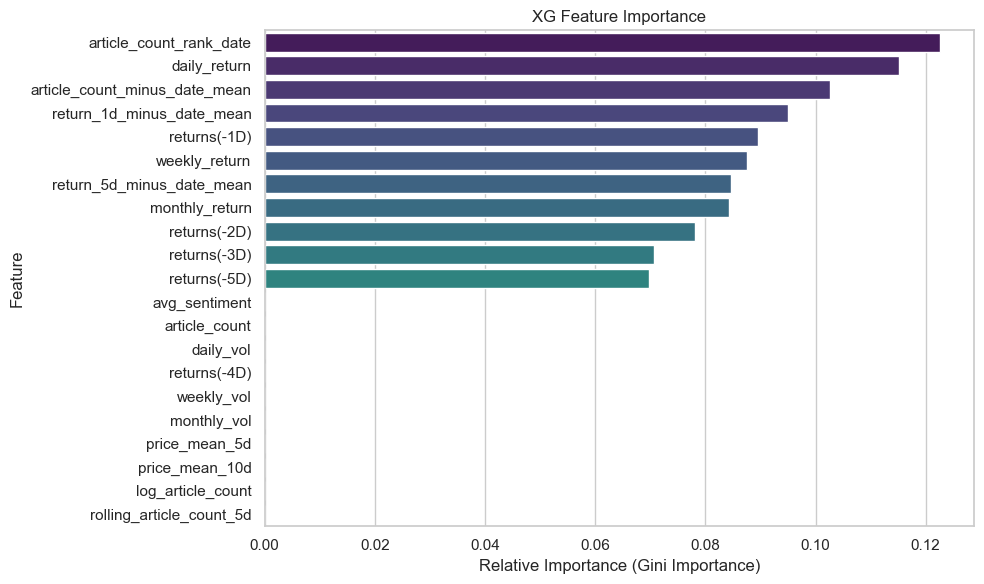

In [37]:
# Extracting the feature names and importances from best tuned model
feature_names_xgb = best_xgb_model.feature_names_in_
importances_xgb = best_xgb_model.feature_importances_

# Creating a DataFrame pairing the feature names with their importance scores
feature_importance_df_xgb = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# Displaing the exact numeric values
print("--- FEATURE IMPORTANCE SCORES ---")
print(feature_importance_df_xgb.to_string(index=False))

# Creating a horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')

plt.title('XG Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model: LSTM (Sequence Model - Numeric Features)

In [38]:
# LSTM workflow with validation split + early stopping
from copy import deepcopy


def build_ticker_sequences(source_df, feature_cols, target_col, seq_len):
    """Create rolling fixed-length sequences per ticker sorted by date."""
    xs, ys = [], []
    sorted_df = source_df.sort_values(["Ticker", "Date"]).copy()

    for _, group in sorted_df.groupby("Ticker", sort=False):
        values = group[feature_cols].to_numpy(dtype=np.float32)
        labels = group[target_col].to_numpy(dtype=np.float32)

        if len(group) < seq_len:
            continue

        for i in range(seq_len - 1, len(group)):
            xs.append(values[i - seq_len + 1 : i + 1])
            ys.append(labels[i])

    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


class SmallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=layers,
            dropout=dropout if layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.out(self.dropout(output[:, -1, :])).squeeze(1)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

    return running_loss / max(len(loader), 1)


def predict_probs(model, loader, device):
    model.eval()
    probs = []
    with torch.no_grad():
        for (batch_x, *_) in loader:
            batch_x = batch_x.to(device)
            batch_probs = torch.sigmoid(model(batch_x)).cpu().numpy()
            probs.append(batch_probs)
    return np.concatenate(probs)


# Reproducibility + device
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training LSTM on: {device}")


# Use same numeric feature set as baseline tree models
lstm_features = list(X_train.columns)
seq_len = 10


# Build a time-based validation split from the training period
train_dates = np.sort(train["Date"].unique())
val_cut_idx = int(len(train_dates) * 0.85)
val_cut_date = train_dates[val_cut_idx]

train_inner = train[train["Date"] < val_cut_date].copy()
val_inner = train[train["Date"] >= val_cut_date].copy()

print(f"Validation cutoff date: {val_cut_date}")
print(f"train_inner rows: {len(train_inner):,}")
print(f"val_inner rows: {len(val_inner):,}")
print(f"test rows: {len(test):,}")


# Fit scaler only on train_inner, then transform validation/test
scaler_lstm = StandardScaler().fit(train_inner[lstm_features])
train_inner_df = train_inner.copy()
val_inner_df = val_inner.copy()
train_full_df = train.copy()
test_lstm_df = test.copy()

train_inner_df[lstm_features] = scaler_lstm.transform(train_inner_df[lstm_features])
val_inner_df[lstm_features] = scaler_lstm.transform(val_inner_df[lstm_features])
train_full_df[lstm_features] = scaler_lstm.transform(train_full_df[lstm_features])
test_lstm_df[lstm_features] = scaler_lstm.transform(test_lstm_df[lstm_features])


# Build ticker-level rolling sequences
X_train_inner, y_train_inner = build_ticker_sequences(
    train_inner_df, lstm_features, "target_next_day_direction", seq_len
)
X_val_lstm, y_val_lstm = build_ticker_sequences(
    val_inner_df, lstm_features, "target_next_day_direction", seq_len
)
X_train_full, y_train_full = build_ticker_sequences(
    train_full_df, lstm_features, "target_next_day_direction", seq_len
)
X_test_lstm, y_test_lstm = build_ticker_sequences(
    test_lstm_df, lstm_features, "target_next_day_direction", seq_len
)

print("LSTM train_inner sequences:", X_train_inner.shape)
print("LSTM validation sequences:", X_val_lstm.shape)
print("LSTM full-train sequences:", X_train_full.shape)
print("LSTM test sequences:", X_test_lstm.shape)


# Data loaders
batch_size = 256
train_inner_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_inner), torch.tensor(y_train_inner)),
    batch_size=batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_lstm), torch.tensor(y_val_lstm)),
    batch_size=batch_size,
    shuffle=False,
)
train_full_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_full), torch.tensor(y_train_full)),
    batch_size=batch_size,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_lstm), torch.tensor(y_test_lstm)),
    batch_size=batch_size,
    shuffle=False,
)


Training LSTM on: cpu
Validation cutoff date: 2022-06-02T00:00:00.000000000
train_inner rows: 878,618
val_inner rows: 160,797
test rows: 270,096
LSTM train_inner sequences: (874154, 10, 21)
LSTM validation sequences: (156315, 10, 21)
LSTM full-train sequences: (1034933, 10, 21)
LSTM test sequences: (265587, 10, 21)


In [39]:
# Tune epochs with early stopping on validation ROC-AUC
max_epochs = 30
patience = 10

lstm_tune = SmallLSTM(input_size=len(lstm_features), hidden_size=64, layers=2, dropout=0.2).to(device)
optimizer_tune = torch.optim.Adam(lstm_tune.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

best_val_auc = -np.inf
best_epoch = 1
epochs_no_improve = 0

# Track loss history for plotting
lstm_train_epochs = []
lstm_train_loss_history = []
lstm_val_roc_auc_history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(lstm_tune, train_inner_loader, optimizer_tune, criterion, device)

    val_probs = predict_probs(lstm_tune, val_loader, device)
    val_auc = roc_auc_score(y_val_lstm.astype(int), val_probs)

    lstm_train_epochs.append(epoch)
    lstm_train_loss_history.append(train_loss)
    lstm_val_roc_auc_history.append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch={best_epoch}, best val_auc={best_val_auc:.4f}")
            break


# Retrain on full training period for the selected epoch count
lstm_model = SmallLSTM(input_size=len(lstm_features), hidden_size=64, layers=2, dropout=0.2).to(device)
optimizer_final = torch.optim.Adam(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)

for epoch in range(1, best_epoch + 1):
    full_loss = train_one_epoch(lstm_model, train_full_loader, optimizer_final, criterion, device)
    print(f"Final train epoch {epoch:02d}/{best_epoch} | loss={full_loss:.4f}")


# Predict on test sequences
probs_lstm = predict_probs(lstm_model, test_loader, device)
pred_lstm = (probs_lstm >= 0.5).astype(int)


# Save for later ROC plotting
y_test_lstm = y_test_lstm.astype(int)


# Add LSTM to the main model comparison table
lstm_metrics = metrics("LSTM (Numeric Sequences, Early Stopping)", y_test_lstm, pred_lstm, probs_lstm)
model_results = pd.concat([model_results, lstm_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))


Epoch 01 | train_loss=0.6913 | val_auc=0.5045
Epoch 02 | train_loss=0.6908 | val_auc=0.5045
Epoch 03 | train_loss=0.6902 | val_auc=0.4999
Epoch 04 | train_loss=0.6893 | val_auc=0.4944
Epoch 05 | train_loss=0.6874 | val_auc=0.4764
Epoch 06 | train_loss=0.6853 | val_auc=0.4633
Epoch 07 | train_loss=0.6835 | val_auc=0.4746
Epoch 08 | train_loss=0.6815 | val_auc=0.4880
Epoch 09 | train_loss=0.6796 | val_auc=0.4932
Epoch 10 | train_loss=0.6774 | val_auc=0.4940
Epoch 11 | train_loss=0.6748 | val_auc=0.4991
Epoch 12 | train_loss=0.6717 | val_auc=0.4905
Early stopping at epoch 12. Best epoch=2, best val_auc=0.5045
Final train epoch 01/2 | loss=0.6917
Final train epoch 02/2 | loss=0.6915

--- Confusion Matrix: LSTM (Numeric Sequences, Early Stopping) ---
          Predicted 0  Predicted 1
Actual 0         3480       122529
Actual 1         3644       135934

True Negatives (TN):  3480
False Positives (FP): 122529
False Negatives (FN): 3644
True Positives (TP):  135934


--- Summary of Model Met

Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
Majority Baseline,0.523240,0.500000,0.687009,0.523240,1.000000
Random Baseline,0.500881,0.500000,0.522401,0.523113,0.521691
Random Forest (Numeric),0.523588,0.511108,0.675097,0.524827,0.945940
XGBoost (Numeric),0.522092,0.510135,0.677812,0.523608,0.960757
"LSTM (Numeric Sequences, Early Stopping)",0.524928,0.511257,0.683015,0.525932,0.973893


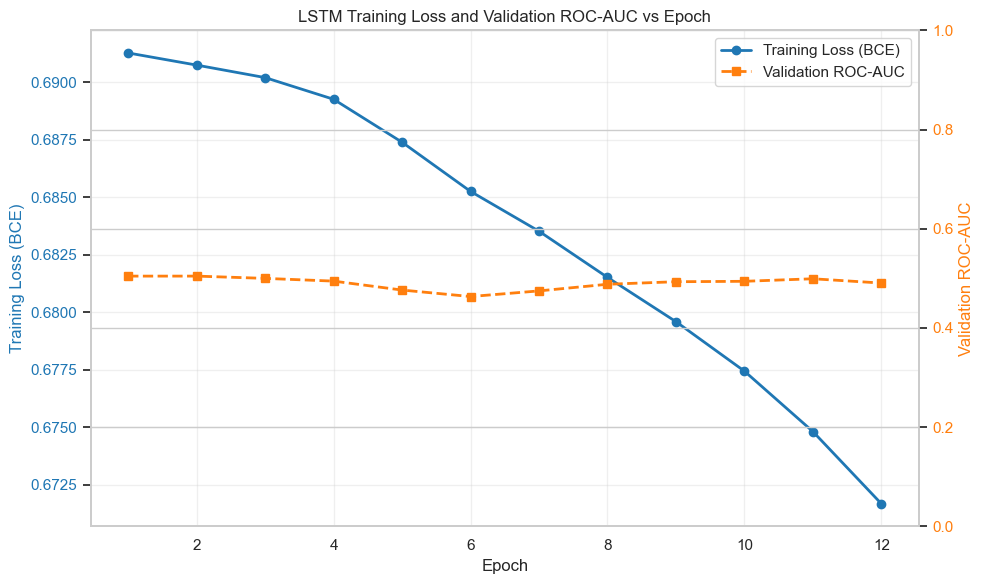

In [40]:
# Plot LSTM training loss and validation ROC-AUC vs epoch
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: training loss
line1 = ax1.plot(
    lstm_train_epochs,
    lstm_train_loss_history,
    marker='o',
    linewidth=2,
    color='tab:blue',
    label='Training Loss (BCE)'
)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss (BCE)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

# Right axis: validation ROC-AUC
ax2 = ax1.twinx()
line2 = ax2.plot(
    lstm_train_epochs,  # use same epoch index
    lstm_val_roc_auc_history,
    marker='s',
    linewidth=2,
    linestyle='--',
    color='tab:orange',
    label='Validation ROC-AUC'
)
ax2.set_ylabel('Validation ROC-AUC', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylim(0.0, 1.0)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title('LSTM Training Loss and Validation ROC-AUC vs Epoch')
plt.tight_layout()
plt.show()

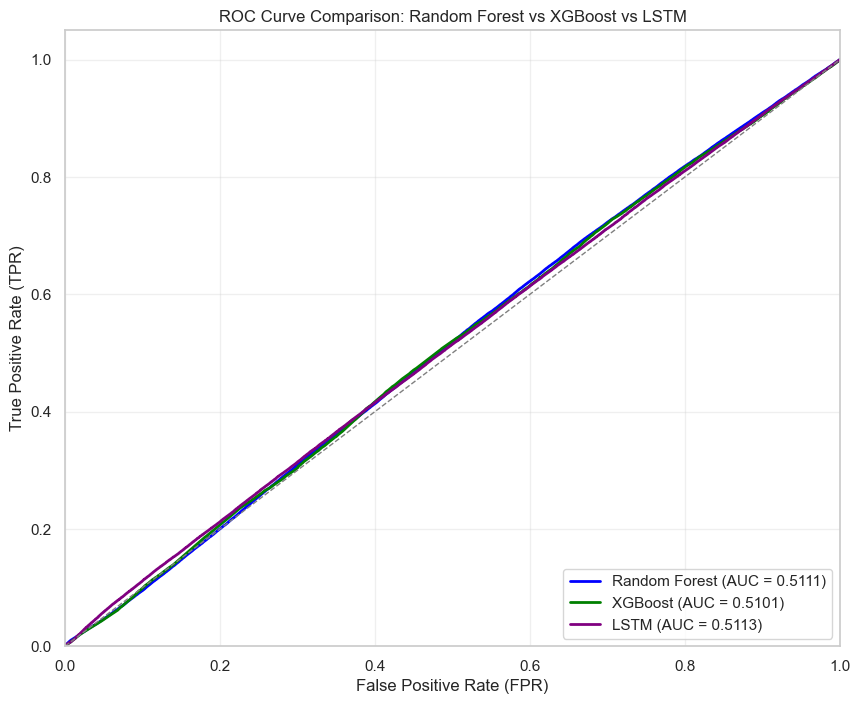

In [41]:
# Calculating ROC curve for Random Forest
FP_rate_rf, TP_rate_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(FP_rate_rf, TP_rate_rf)

# Calculating ROC curve for XGBoost (numeric)
FP_rate_xgb, TP_rate_xgb, _ = roc_curve(y_test_xgb, y_pred_proba_xgb_best)
roc_auc_xgb = auc(FP_rate_xgb, TP_rate_xgb)

# Calculating ROC curve for LSTM
FP_rate_lstm, TP_rate_lstm, _ = roc_curve(y_test_lstm, probs_lstm)
roc_auc_lstm = auc(FP_rate_lstm, TP_rate_lstm)

# Plotting the ROC curves
plt.figure(figsize=(10, 8))

plt.plot(FP_rate_rf, TP_rate_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(FP_rate_xgb, TP_rate_xgb, color='green', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(FP_rate_lstm, TP_rate_lstm, color='purple', lw=2, label=f'LSTM (AUC = {roc_auc_lstm:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison: Random Forest vs XGBoost vs LSTM')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Model: XGBoost Classifier (Numerical + Categorical)

In [42]:
# Creating list of excluded features (X)
exclude_columns_xgb2 = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    # 'Sector', 'Industry',               # Categorical
    'Open', 'High', 'Low', 'Close',     # Raw prices
    'Volume',                           # Raw Volume
    'target_next_day_direction'         # The target variable
]

# Separating features (X) and target (y)
X_train_xgb2 = train.drop(columns = exclude_columns_xgb2)
y_train_xgb2 = train['target_next_day_direction']

X_test_xgb2 = test.drop(columns = exclude_columns_xgb2)
y_test_xgb2 = test['target_next_day_direction']

# Optional: Print the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train_xgb2.columns)


Features used for modeling:
Index(['Sector', 'Industry', 'avg_sentiment', 'article_count', 'daily_return',
       'daily_vol', 'weekly_return', 'weekly_vol', 'monthly_return',
       'monthly_vol', 'returns(-1D)', 'returns(-2D)', 'returns(-3D)',
       'returns(-4D)', 'returns(-5D)', 'price_mean_5d', 'price_mean_10d',
       'return_1d_minus_date_mean', 'return_5d_minus_date_mean',
       'log_article_count', 'article_count_rank_date',
       'article_count_minus_date_mean', 'rolling_article_count_5d'],
      dtype='object')


In [43]:
# Generating model with enable_categorical=True and use the 'hist' tree method
model = xgb.XGBClassifier(
    n_estimators=50, 
    max_depth=8, 
    learning_rate=0.05, 
    random_state=42,
    tree_method='hist',           
    enable_categorical=True       
)
model.fit(X_train_xgb2, y_train_xgb2)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [44]:
# Getting predictions and probabilities
pred_xgb2 = model.predict(X_test_xgb2)
probs_xgb2 = model.predict_proba(X_test_xgb2)[:, 1]

xgb_cat_metrics = metrics("XGBoost (Numeric + Categorical)", y_test_xgb2, pred_xgb2, probs_xgb2)

# Displaying metrics from models
model_results = pd.concat([model_results, xgb_cat_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Confusion Matrix: XGBoost (Numeric + Categorical) ---
          Predicted 0  Predicted 1
Actual 0        24821       103950
Actual 1        25669       115656

True Negatives (TN):  24821
False Positives (FP): 103950
False Negatives (FN): 25669
True Positives (TP):  115656


--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
Majority Baseline,0.523240,0.500000,0.687009,0.523240,1.000000
Random Baseline,0.500881,0.500000,0.522401,0.523113,0.521691
Random Forest (Numeric),0.523588,0.511108,0.675097,0.524827,0.945940
XGBoost (Numeric),0.522092,0.510135,0.677812,0.523608,0.960757
"LSTM (Numeric Sequences, Early Stopping)",0.524928,0.511257,0.683015,0.525932,0.973893
XGBoost (Numeric + Categorical),0.520100,0.503708,0.640876,0.526652,0.818369


--- Exact Feature Importance Scores (Normalized) ---
                      Feature  Relative Importance  Percentage (%)
      article_count_rank_date             0.145163           14.52
article_count_minus_date_mean             0.140154           14.02
                     Industry             0.068564            6.86
                 daily_return             0.061730            6.17
                 returns(-1D)             0.053586            5.36
                 returns(-5D)             0.050048            5.00
                 returns(-3D)             0.047957            4.80
                article_count             0.047608            4.76
               monthly_return             0.047322            4.73
                weekly_return             0.044981            4.50
    return_1d_minus_date_mean             0.043581            4.36
                 returns(-2D)             0.039842            3.98
                 returns(-4D)             0.036671            3.67
    retur

<Figure size 1000x800 with 0 Axes>

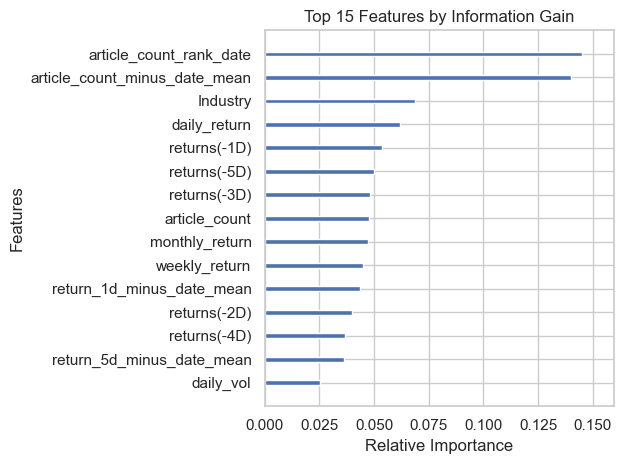

In [45]:
# Visualizing Feature Importance

# Get the exact numerical scores for 'gain'
raw_scores = model.get_booster().get_score(importance_type='gain')

# Normalizing raw scoresto sort in library
total_gain = sum(raw_scores.values())
normalized_scores = {feature: (score / total_gain) for feature, score in raw_scores.items()}
sorted_normalized = dict(sorted(normalized_scores.items(), key=lambda item: item[1], reverse=True))

# Converting the sorted dictionary into a DataFrame
normalized_df = pd.DataFrame({
    'Feature': list(sorted_normalized.keys()),
    'Relative Importance': list(sorted_normalized.values())
})

# Createing a clean percentage column for easier reading
normalized_df['Percentage (%)'] = (normalized_df['Relative Importance'] * 100).round(2)

# Print the clean DataFrame without the index numbers
print("--- Exact Feature Importance Scores (Normalized) ---")
print(normalized_df.to_string(index=False))

# Displaying importance features
plt.figure(figsize=(10, 8))

# Plotting using xgb's built-in plot_importance()
xgb.plot_importance(
    normalized_scores, 
    max_num_features=15,       # Change this to see more or fewer features
    show_values=False,         # Hides the raw numbers on the bars for a cleaner look
    title='Top 15 Features by Information Gain',
    xlabel = 'Relative Importance'
)

plt.tight_layout()
plt.show()


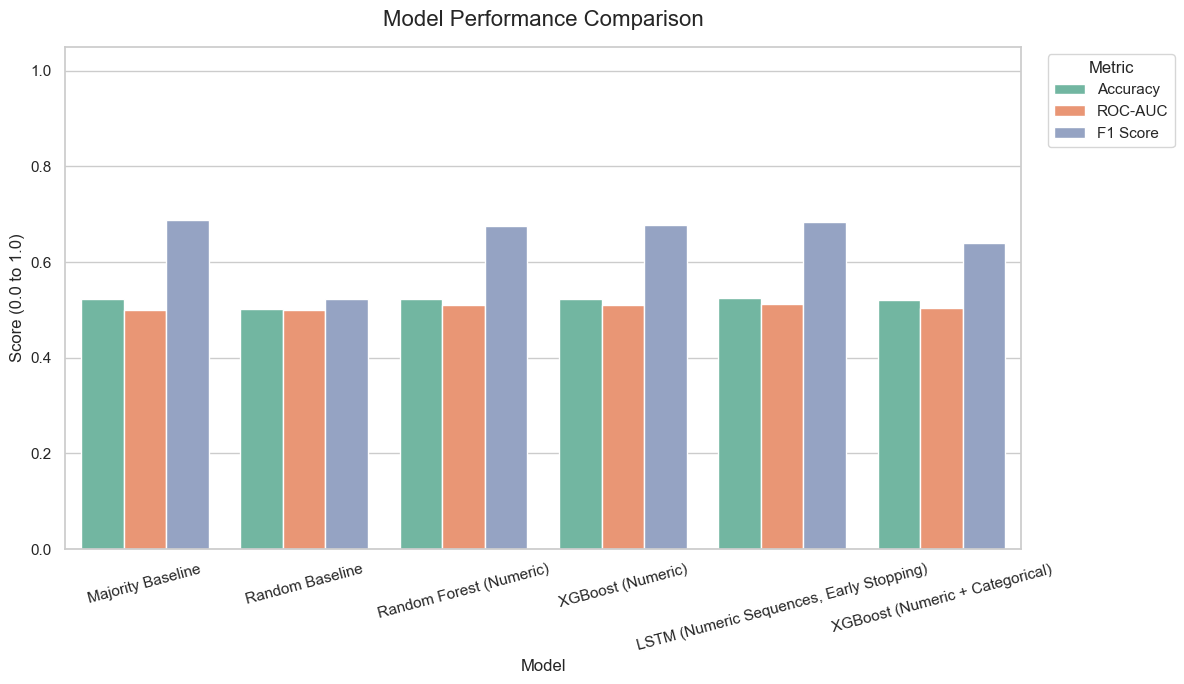

In [46]:
# 1. Select only the core metrics we want to plot
core_metrics_df = model_results[['Model', 'Accuracy', 'ROC-AUC', 'F1 Score']]

# 2. "Melt" the dataframe so Seaborn can plot it as grouped bars
# This turns the columns into rows, categorizing them by 'Metric'
melted_df = core_metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. Set up the plot aesthetics
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 4. Create the grouped bar chart
sns.barplot(
    data=melted_df, 
    x='Model', 
    y='Score', 
    hue='Metric', 
    palette='Set2' # 'Set2' provides nice, distinct academic colors
)

# 5. Format the chart
plt.title('Model Performance Comparison', fontsize=16, pad=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.05) # Lock the y-axis from 0 to 1 so the baseline differences are clear

# Rotate x-axis labels if your model names are long
plt.xticks(rotation=15)

# Move the legend outside the plot area
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adjust layout and show
plt.tight_layout()
plt.show()

NOTE: Features show model priorities 


---

In [47]:
print(df.columns)

Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count',
       'daily_return', 'daily_vol', 'weekly_return', 'weekly_vol',
       'monthly_return', 'monthly_vol', 'returns(-1D)', 'returns(-2D)',
       'returns(-3D)', 'returns(-4D)', 'returns(-5D)', 'price_mean_5d',
       'price_mean_10d', 'return_1d_minus_date_mean',
       'return_5d_minus_date_mean', 'log_article_count',
       'article_count_rank_date', 'article_count_minus_date_mean',
       'rolling_article_count_5d', 'target_next_day_direction'],
      dtype='object')


# Sectors

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\702873468.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2022_present.groupby('Industry')['article_count']
C:\Users\crist\AppData\Local\Temp\ipykernel_16872\702873468.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_industry_counts = df_2022_present.groupby(['Date', 'Industry'])['article_count'].sum().reset_index()


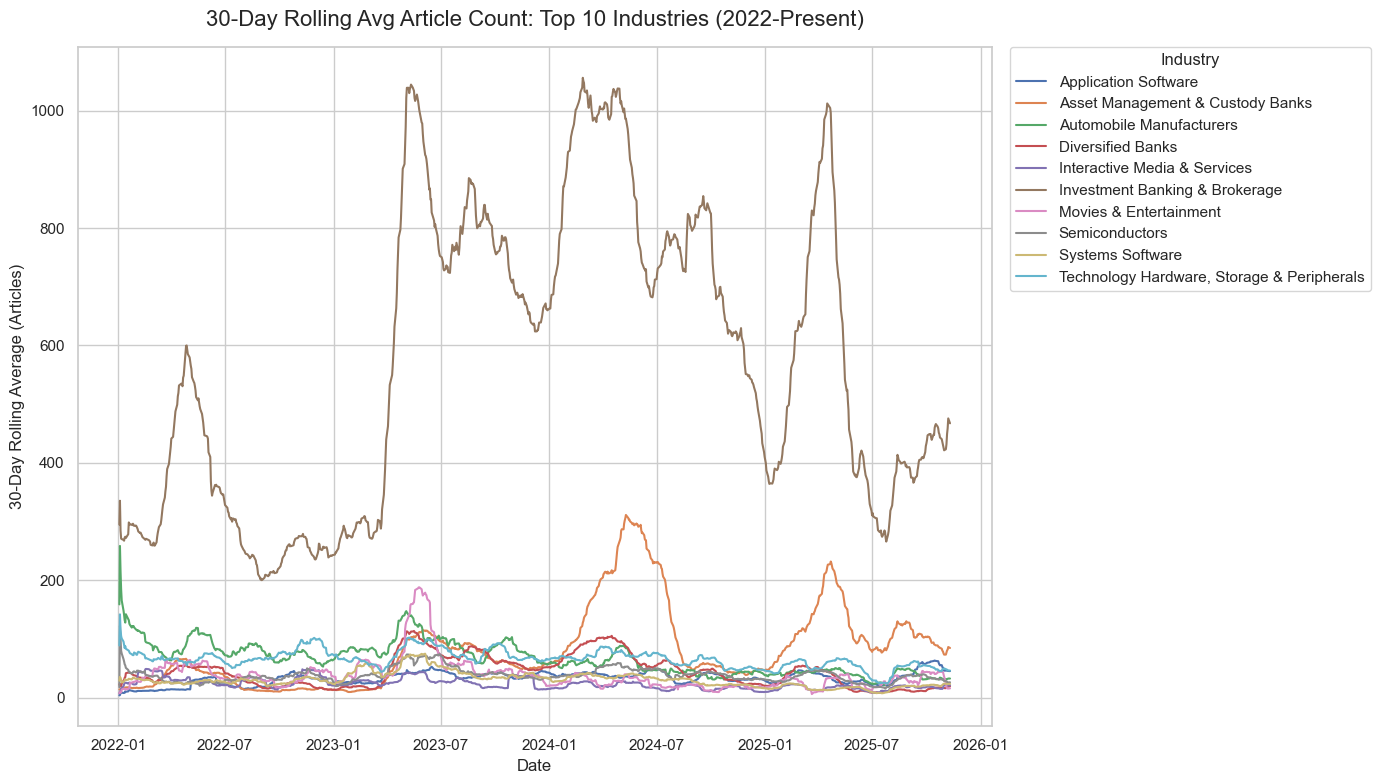

In [48]:
df_2022_present = df[df['Date'] >= '2022-01-01'].copy()

# 2. Identify the top 10 most talked-about industries in this timeframe
top_10_industries = (
    df_2022_present.groupby('Industry')['article_count']
    .sum()
    .nlargest(10)
    .index
)

# 3. Get the daily total article count for all industries
daily_industry_counts = df_2022_present.groupby(['Date', 'Industry'])['article_count'].sum().reset_index()

# 4. Filter the daily counts to only include our top 10 industries
top_10_daily = daily_industry_counts[daily_industry_counts['Industry'].isin(top_10_industries)].copy()

# 4.5 FIX: Cast the column to a string to erase the unused categories from the legend
top_10_daily['Industry'] = top_10_daily['Industry'].astype(str)

# 5. Sort by Date and calculate the 30-day rolling average
top_10_daily = top_10_daily.sort_values('Date')
top_10_daily['rolling_30d_avg'] = (
    top_10_daily.groupby('Industry')['article_count']
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
)

# 6. Set up the plot aesthetics
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 7. Create the line chart
sns.lineplot(
    data=top_10_daily, 
    x='Date', 
    y='rolling_30d_avg', 
    hue='Industry',
    linewidth=1.5
)

# 8. Format the titles and labels
plt.title('30-Day Rolling Avg Article Count: Top 10 Industries (2022-Present)', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('30-Day Rolling Average (Articles)', fontsize=12)

# 9. Move the legend outside the plot
plt.legend(title='Industry', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# 10. Adjust layout and display
plt.tight_layout()
plt.show()

In [49]:
top_10_daily.head()

,Date,Industry,article_count,rolling_30d_avg
8,2022-01-03,Application Software,4,4.0
9,2022-01-03,Asset Management & Custody Banks,14,14.0
10,2022-01-03,Automobile Manufacturers,159,159.0
35,2022-01-03,Diversified Banks,23,23.0
76,2022-01-03,Interactive Media & Services,7,7.0


C:\Users\crist\AppData\Local\Temp\ipykernel_16872\1205666787.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2022_present.groupby('Industry')['article_count']
C:\Users\crist\AppData\Local\Temp\ipykernel_16872\1205666787.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_industry_counts = df_2022_present.groupby(['Year', 'Industry'])['article_count'].sum().reset_index()


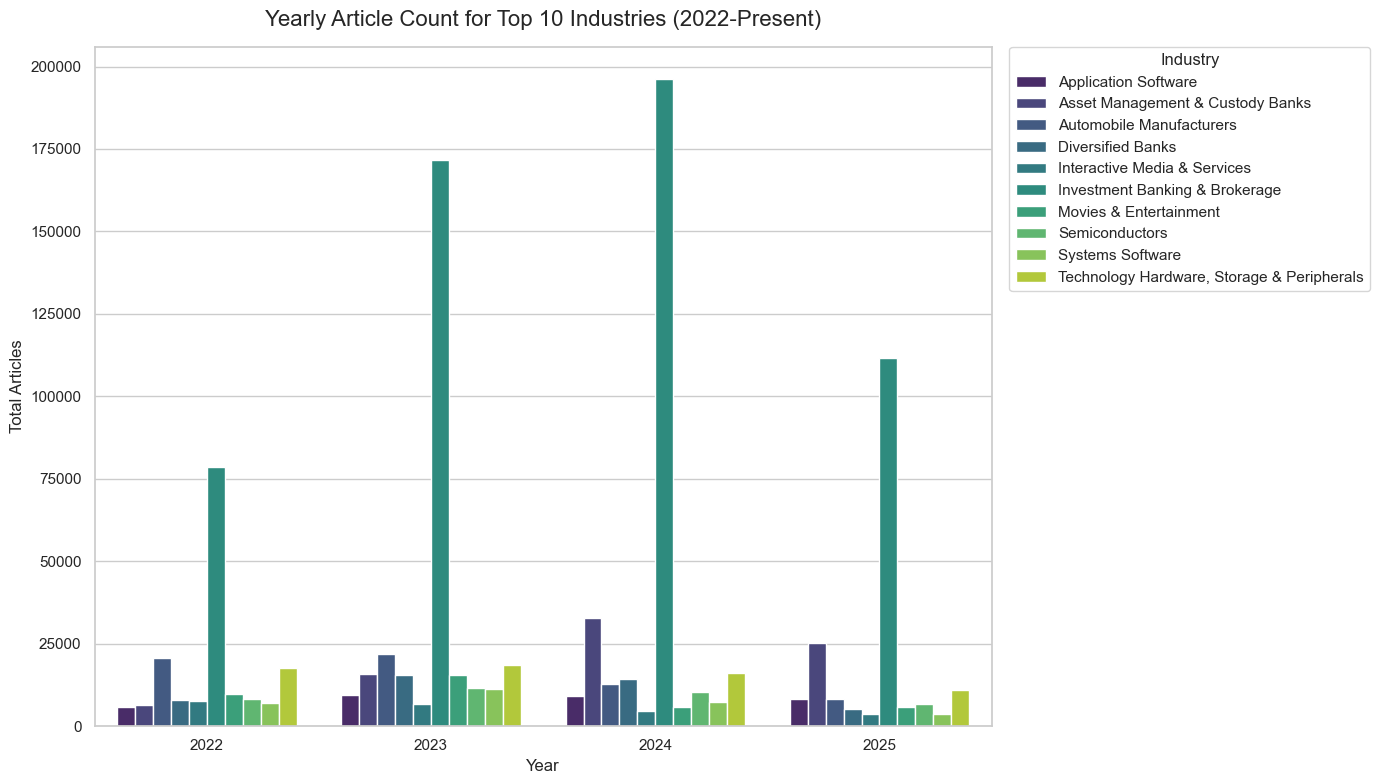

In [50]:
df_2022_present = df[df['Date'] >= '2022-01-01'].copy()

# 2. Create a new 'Year' column from the Date
df_2022_present['Year'] = df_2022_present['Date'].dt.year

# 3. Identify the overall top 10 industries in this timeframe
top_10_industries = (
    df_2022_present.groupby('Industry')['article_count']
    .sum()
    .nlargest(10)
    .index
)

# 4. Group the data by both Year and Industry, then sum the articles
yearly_industry_counts = df_2022_present.groupby(['Year', 'Industry'])['article_count'].sum().reset_index()

# 5. Filter the data to only include our top 10 industries
top_10_yearly = yearly_industry_counts[yearly_industry_counts['Industry'].isin(top_10_industries)].copy()

# 6. FIX: Cast to string to prevent empty categories from appearing in the legend
top_10_yearly['Industry'] = top_10_yearly['Industry'].astype(str)

# 7. Set up the plot aesthetics
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 8. Create the grouped bar chart
sns.barplot(
    data=top_10_yearly, 
    x='Year', 
    y='article_count', 
    hue='Industry',
    palette='viridis'
)

# 9. Format the titles and labels
plt.title('Yearly Article Count for Top 10 Industries (2022-Present)', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Articles', fontsize=12)

# 10. Move the legend outside the plot so it doesn't overlap the bars
plt.legend(title='Industry', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# 11. Adjust layout and display
plt.tight_layout()
plt.show()

In [51]:
top_10_yearly.head()

,Year,Industry,article_count
8,2022,Application Software,5929
9,2022,Asset Management & Custody Banks,6507
10,2022,Automobile Manufacturers,20576
35,2022,Diversified Banks,7972
76,2022,Interactive Media & Services,7557


## Predicting by Industry 

In [54]:
# FUNCTION: Engineered Features for Industry
def engineer_features(industry_df):
    
    # Returns
    industry_df['daily_return'] = industry_df['Close'].pct_change()
    industry_df['weekly_return'] = industry_df['Close'].pct_change(periods=5)
    industry_df['monthly_return'] = industry_df['Close'].pct_change(periods=21)
    industry_df['quarterly_return'] = industry_df['Close'].pct_change(periods=63)
    
    # Volume Change
    industry_df['vol_change'] = industry_df['Volume'].pct_change()
    
    # Lags
    for lag in range(1, 6):
        industry_df[f'returns(-{lag}D)'] = industry_df['daily_return'].shift(lag)
    
    # 7-day simple moving average
    industry_df['article_7d_SMA'] = industry_df['article_count'].rolling(window=7).mean()
    industry_df['sentiment_7d_SMA'] = industry_df['avg_sentiment'].rolling(window=7).mean()
    
    # Simple Moving Average
    industry_df['SMA_3'] = ta.sma(industry_df['Close'], length=3)
    industry_df['SMA_4'] = ta.sma(industry_df['Close'], length=4)
    industry_df['SMA_20'] = ta.sma(industry_df['Close'], length=20)
    industry_df['SMA_50'] = ta.sma(industry_df['Close'], length=50)
    industry_df['RSI_14'] = ta.rsi(industry_df['Close'], length=14)
    
    industry_df['target'] = (industry_df['Close'].shift(-1) > industry_df['Close']).astype(int)
    industry_df.dropna(inplace=True)
    
    return industry_df

In [55]:
# FUNCTION: Training and Evaluating RF and XGBoost models
def train_and_evaluate_models(industry, X_train, X_test, y_train, y_test):
    results = []
    
    # --- 1. Random Forest ---
    print(f"\n{'='*40}\nEvaluating Random Forest for: {industry}\n{'='*40}")
    rf_model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        min_samples_leaf=10, 
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    rf_metrics = metrics(
        model_name=f"{industry} (Random Forest)", 
        y_true=y_test, 
        y_pred=rf_model.predict(X_test), 
        y_prob=rf_model.predict_proba(X_test)[:, 1]
    )
    results.append(rf_metrics)
    
    # --- 2. XGBoost ---
    print(f"\n{'='*40}\nEvaluating XGBoost for: {industry}\n{'='*40}")
    xgb_model = XGBClassifier(
        n_estimators=100, 
        learning_rate=0.05, 
        max_depth=4, 
        random_state=42,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train)
    xgb_metrics = metrics(
        model_name=f"{industry} (XGBoost)", 
        y_true=y_test, 
        y_pred=xgb_model.predict(X_test), 
        y_prob=xgb_model.predict_proba(X_test)[:, 1]
    )
    results.append(xgb_metrics)
    
    return rf_metrics, xgb_metrics

In [56]:
# Creating dictionary to store the results of our models
all_industry_metrics = []
rf_metrics_list = []
xgb_metrics_list = []

# Filtering original dataframe for only the top 10 industries
industry_list = top_10_yearly['Industry'].unique().tolist()
df_top10 = df[df['Industry'].isin(top_10_industries)].copy()

# Aggregating data to the Industry level (Creating an "Industry Index")
industry_df = df_top10.groupby(['Date', 'Industry']).agg({
    'Close': 'sum',
    'Volume': 'sum',
    'article_count': 'sum',
    'avg_sentiment': 'mean'
}).reset_index()

print("--- TRAINING MODELS BY INDUSTRY ---")

# Iterating through each industry, build features, and train a model
for industry in top_10_industries:
    
    industry_data = industry_df[industry_df['Industry'] == industry].copy()
    industry_data = industry_data.sort_values('Date').reset_index(drop=True)
    
    # Generating features and target
    industry_data = engineer_features(industry_data)
    industry_data['target'] = (industry_data['Close'].shift(-1) > industry_data['Close']).astype(int)
        
    # Drop NaNs created by rolling windows/shifts
    industry_data.dropna(inplace=True)
    
    # Separating features and target for modeling
    features = [col for col in industry_data.columns if col not in ['Date', 'Industry', 'target', 'Close', 'Volume']]
    X = industry_data[features]
    y = industry_data['target']

    # Splitting data 80/20
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Train both models and collect the results
    rf_result, xgb_result = train_and_evaluate_models(industry, X_train, X_test, y_train, y_test)
    
    rf_metrics_list.append(rf_result)
    xgb_metrics_list.append(xgb_result)
    

# Combine Random Forest metrics, sort, and display
final_metrics_rf = pd.concat(rf_metrics_list, ignore_index=True)
final_metrics_rf = final_metrics_rf.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("\n\n=== FINAL INDUSTRY MODEL LEADERBOARD (RANDOM FOREST) ===")
display(final_metrics_rf)

# Combine XGBoost metrics, sort, and display
final_metrics_xgb = pd.concat(xgb_metrics_list, ignore_index=True)
final_metrics_xgb = final_metrics_xgb.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("\n\n=== FINAL INDUSTRY MODEL LEADERBOARD (XGBOOST) ===")
display(final_metrics_xgb)

C:\Users\crist\AppData\Local\Temp\ipykernel_16872\861564008.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  industry_df = df_top10.groupby(['Date', 'Industry']).agg({


--- TRAINING MODELS BY INDUSTRY ---

Evaluating Random Forest for: Investment Banking & Brokerage

--- Confusion Matrix: Investment Banking & Brokerage (Random Forest) ---
          Predicted 0  Predicted 1
Actual 0          215           14
Actual 1          284           15

True Negatives (TN):  215
False Positives (FP): 14
False Negatives (FN): 284
True Positives (TP):  15

Evaluating XGBoost for: Investment Banking & Brokerage

--- Confusion Matrix: Investment Banking & Brokerage (XGBoost) ---
          Predicted 0  Predicted 1
Actual 0          200           29
Actual 1          253           46

True Negatives (TN):  200
False Positives (FP): 29
False Negatives (FN): 253
True Positives (TP):  46

Evaluating Random Forest for: Asset Management & Custody Banks

--- Confusion Matrix: Asset Management & Custody Banks (Random Forest) ---
          Predicted 0  Predicted 1
Actual 0          219           17
Actual 1          259           33

True Negatives (TN):  219
False Positives 

,Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
0,Asset Management & Custody Banks (Random Forest),0.477273,0.566113,0.192982,0.660000,0.113014
1,"Technology Hardware, Storage & Peripherals (Ra...",0.464015,0.548393,0.095847,0.681818,0.051546
2,Interactive Media & Services (Random Forest),0.481061,0.541197,0.208092,0.631579,0.124567
3,Semiconductors (Random Forest),0.517045,0.541063,0.243323,0.672131,0.148551
4,Automobile Manufacturers (Random Forest),0.518939,0.535242,0.531365,0.531365,0.531365
5,Movies & Entertainment (Random Forest),0.473485,0.519693,0.252688,0.546512,0.164336
6,Systems Software (Random Forest),0.484848,0.514532,0.392857,0.556962,0.303448
7,Application Software (Random Forest),0.517045,0.504322,0.592000,0.564024,0.622896
8,Investment Banking & Brokerage (Random Forest),0.435606,0.502110,0.091463,0.517241,0.050167
9,Diversified Banks (Random Forest),0.446970,0.492455,0.093168,0.517241,0.051195




=== FINAL INDUSTRY MODEL LEADERBOARD (XGBOOST) ===


,Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall
0,Automobile Manufacturers (XGBoost),0.535985,0.544546,0.547135,0.548148,0.546125
1,Movies & Entertainment (XGBoost),0.511364,0.538606,0.424107,0.586420,0.332168
2,Interactive Media & Services (XGBoost),0.498106,0.537114,0.415011,0.573171,0.325260
3,Semiconductors (XGBoost),0.517045,0.534018,0.312668,0.610526,0.210145
4,Asset Management & Custody Banks (XGBoost),0.505682,0.532331,0.481113,0.573460,0.414384
5,"Technology Hardware, Storage & Peripherals (XG...",0.488636,0.531631,0.304124,0.608247,0.202749
6,Application Software (XGBoost),0.479167,0.513228,0.324324,0.600000,0.222222
7,Systems Software (XGBoost),0.498106,0.512359,0.479371,0.557078,0.420690
8,Investment Banking & Brokerage (XGBoost),0.465909,0.503147,0.245989,0.613333,0.153846
9,Diversified Banks (XGBoost),0.464015,0.487053,0.264935,0.554348,0.174061


In [57]:
# Notebook runtime tracker (end)
notebook_end_time = time.time()
elapsed_seconds = notebook_end_time - notebook_start_time
elapsed_minutes = elapsed_seconds / 60

print(f"Total notebook runtime: {elapsed_seconds:.2f} seconds ({elapsed_minutes:.2f} minutes)")

Total notebook runtime: 4324.37 seconds (72.07 minutes)
